# Mathematical description

In the previous chapter, compartmental models were introduced in terms of compartments, transitions and events.
This model structure exists without the need to commit to any particular method of simulation.

Now, we introduce mathematical objects that represent these concepts which allow for two ways to find solutions:

1) Continuous-Time Markov Chains (CTMCs), which model the stochastic occurrence of individual events.
2) Ordinary Differential Equations (ODEs), which describe the average behaviour of those events.

For illustration, we continue to use the extended SIR model (with births and deaths) introduced previously:

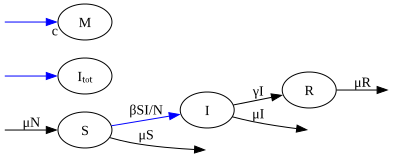

In [2]:
from graphviz import Digraph

dot = Digraph()

dot.body.extend(['rankdir=LR'])

states=['S', 'I', 'R']

for s in states:
    dot.node(s)

dot.edge('S', 'I', label='&beta;SI/N', color="blue")
dot.edge('I', 'R', label='&gamma;I')

dot.node("bornS", label="", shape="none", height="0", width="0")
dot.edge('bornS', 'S', label="&mu;N")

dot.node("deadS", label="", shape="none", height="0", width="0")
dot.edge('S', 'deadS', label="&mu;S")

dot.node("deadI", label="", shape="none", height="0", width="0")
dot.edge('I', 'deadI', label="&mu;I")

dot.node("deadR", label="", shape="none", height="0", width="0")
dot.edge('R', 'deadR', label="&mu;R")

dot.node("I0", label="", shape="none", height="0", width="0")
dot.edge('I0', 'Iₜₒₜ', color="blue")

dot.node("M0", label="", shape="none", height="0", width="0")
dot.edge('M0', 'M', color="blue", headlabel='c')

dot

## State vector

We start with the **state vector**, $\boldsymbol{y}$, describing the populations of the different compartments.

For the extended SIR model:

$$
\begin{aligned}
\boldsymbol{y} =
\begin{pmatrix}
S\\
I\\
R\\
I_{tot}\\
M
\end{pmatrix}
\end{aligned}
$$

## State change matrix

Consider an event, $j$.
When it occurs, the state vector changes as:

$$
\begin{aligned}
\boldsymbol{y} \rightarrow \boldsymbol{y} + \boldsymbol{v}_j
\end{aligned}
$$

where $\boldsymbol{v}_j$​ is the **state-change vector** associated with that event.
For example, the infection event (which we'll say is the event with index 1) has a state change vector:

$$
\begin{aligned}
\boldsymbol{v}_1 =
\begin{pmatrix}
-1\\
1\\
0\\
1\\
c
\end{pmatrix}
\end{aligned}
$$

Note that the state-change vector represents the combined effect of all transitions associated with the event.
Collecting the state-change vectors for all events yields the **state-change matrix** (or **stoichiometry matrix**)

$$
\begin{aligned}
\mathcal{D} = [\boldsymbol{v}_1, \ldots \boldsymbol{v}_{N_E}]
\end{aligned}
$$

where $N_E$ is the total number of events.
The element $\mathcal{D}_{ij}$ gives the change in compartment $i$ caused by an occurance of the event $j$.

For the extended SIR model:

$$
\begin{aligned}
\mathcal{D} =
\begin{pmatrix}
-1 &  0 &  1 & -1 &  0 &  0\\
 1 & -1 &  0 &  0 & -1 &  0\\
 0 &  1 &  0 &  0 &  0 & -1\\
 1 &  0 &  0 &  0 &  0 &  0\\
 c &  0 &  0 &  0 &  0 &  0\\
\end{pmatrix}
\end{aligned}
$$

where the columns refer to state change vectors for infection, recovery, births, S deaths, I deaths and R deaths respectively.

## Event-Rate Vector

Each event occurs at some rate $\lambda_j$​ and these rates are collected into the **event-rate vector**

$$
\begin{aligned}
\boldsymbol{\lambda} =
\begin{pmatrix}
\lambda_1 \\
\vdots \\
\lambda_{N_E}
\end{pmatrix}
\end{aligned}
$$

In the SIR model:

$$
\begin{aligned}
\boldsymbol{\lambda} =
\begin{pmatrix}
\frac{\beta S I}{N} \\
\gamma I \\
\mu N \\
\mu S \\
\mu I \\
\mu R
\end{pmatrix}
\end{aligned}
$$

The state vector $\boldsymbol{y}$, state-change matrix $\mathcal{D}$, and event-rate vector $\boldsymbol{\lambda}$ together define a compartmental model in PyGOM.
We now introduce the two related, but distinct, ways a compartmental model can be solved.

## Continuous Time Markov Chains

This event-based formalism follows closely from the mathematical description just outlined.
Here:

- State variables represent discrete counts
- Events cause discrete jumps in the system state

The system evolves through the random occurance of events.
Events occur according to their associated rates and thus their waiting times are exponentially distributed.
The model evolves as a sequence of random jumps between states.

CTMCs are particularly useful when:

- Population sizes are small
- Stochastic effects are important
- Extinction events are possible
- Variability between realisations is of interest

## Ordinary Differential Equations

The ODE description is often viewed as a large-population approximation to the underlying CTMC.
This interpretation departs from previous approach in that:

- State variables are continuous
- Events contribute through continuous flows

The system advances, not due to random occurrences of individual events, but continuously in time through the average effect of all events.
Using matrix multiplication to sum over all events:

$$
\begin{aligned}
\frac{\mathrm{d} \mathbf{y}}{\mathrm{d} t} = \mathcal{D} \boldsymbol{\lambda}
\end{aligned}
$$

Applying this to the extended SIR model:

$$
\begin{aligned}
\frac{\mathrm{d} S}{\mathrm{d} t} &= -\frac{\beta S I}{N} + \mu N - \mu S\\
\frac{\mathrm{d} I}{\mathrm{d} t} &= \frac{\beta S I}{N} - \gamma I - \mu I\\
\frac{\mathrm{d} R}{\mathrm{d} t} &= \gamma I - \mu R\\
\frac{\mathrm{d} I_{\mathrm{tot}}}{\mathrm{d} t} &= \frac{\beta S I}{N}\\
\frac{\mathrm{d} M}{\mathrm{d} t} &= \frac{c \beta S I}{N}
\end{aligned}
$$

This approximation is often appropriate when populations are sufficiently large that random fluctuations are relatively unimportant.

```{warning}
The ODE solution should not generally be interpreted as the mean of a collection of CTMC realisations.
For example, in an epidemic system where a substantial fraction of the realisations go extinct, the ODE solution will closely resemble the trajectories which grow, not reflecting an average of growing and extinct outcomes.
```

## Summary

The same compartmental model may be interpreted in two different ways.

| CTMC      | ODE |
| ----------- | ----------- |
| Discrete state variables      | Continuous state variables       |
| Stochastic   | Deterministic       |
| Events occur individually   | Events contribute through their average effect       |
| Stepped state trajectories | Smooth state trajectories |
| Variability between different realisations | Same result every time |